In [55]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from tensorflow.keras import layers,models
import numpy as np

In [18]:
IMAGE_SIZE=256
BATCH_SIZE=32
CHANNELS=3
EPOCHS=20

In [5]:
dataset=tf.keras.preprocessing.image_dataset_from_directory(
    "training/PlantVillage",
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 2152 files belonging to 3 classes.


In [6]:
class_names=dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [7]:
len(dataset)

68

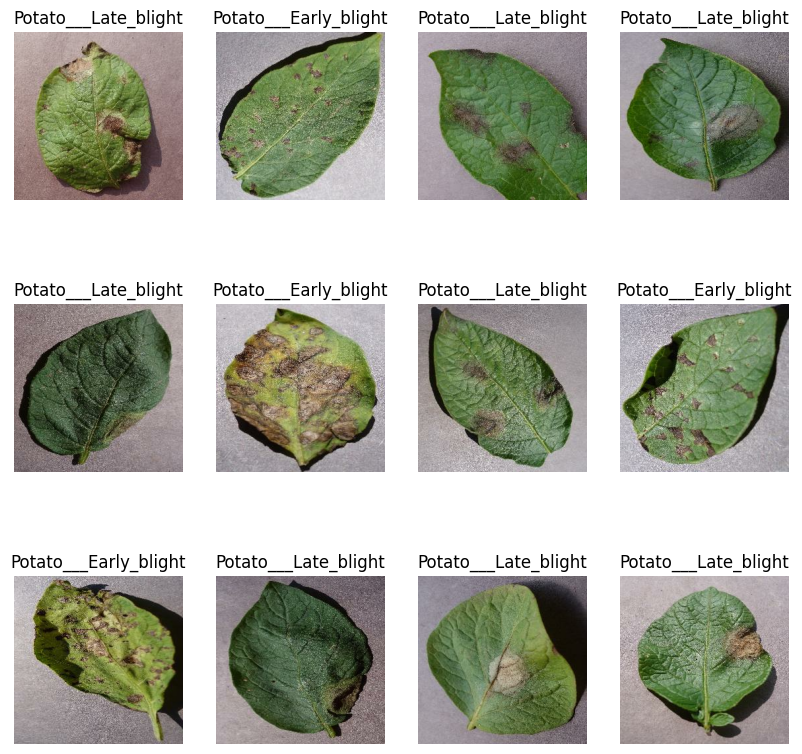

In [15]:
plt.figure(figsize=(10,10))
for image_batch, label_batch in dataset.take(1):
    for i in range(12):
        ax=plt.subplot(3, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])
        plt.axis("off")

In [16]:
len(dataset)

68

In [19]:
#80%==>training
#20%==>10% validation, 10% test

In [20]:
train_size=0.8
len(dataset)*train_size

54.400000000000006

In [21]:
train_ds=dataset.take(54)
len(train_ds)

54

In [22]:
test_ds=dataset.skip(54)
len(test_ds)

14

In [23]:
val_size=0.1
len(dataset)*val_size

6.800000000000001

In [24]:
val_ds=test_ds.take(6)
len(val_ds)

6

In [25]:
test_ds=test_ds.skip(6)
len(test_ds)

8

In [29]:
def get_dataset_partitions_tf(ds,train_split=0.8,val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    ds_size=len(ds)
    if shuffle:
        ds=ds.shuffle(shuffle_size,seed=12)
    
    train_size=int(train_split*ds_size)
    val_size=int(val_split*ds_size)
    test_size=int(test_split*ds_size)

    train_ds=ds.take(train_size)
    val_ds=ds.skip(train_size).take(val_size)
    test_ds=ds.skip(train_size).skip(val_size)

    return train_ds,val_ds,test_ds

In [30]:
train_ds,val_ds,test_ds=get_dataset_partitions_tf(dataset)

In [31]:
len(train_ds),len(val_ds),len(test_ds)

(54, 6, 8)

In [32]:
train_ds=train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds=val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds=test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)


In [36]:
resize_and_rescale=tf.keras.Sequential([
    layers.experimental.preprocessing.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.experimental.preprocessing.Rescaling(1./255)
])

In [ ]:
data_augmentation=tf.keras.Sequential([
    layers.experimental.preprocessing.RandomFlip("horizontal_and_vertical"),
    layers.experimental.preprocessing.RandomRotation(0.2)

])

In [41]:
input_shape=(BATCH_SIZE,IMAGE_SIZE,IMAGE_SIZE,CHANNELS)
n_classes=3
model=models.Sequential([
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(32,(3,3),activation="relu",input_shape=input_shape),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, kernel_size=(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, kernel_size=(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64,activation="relu"),
    layers.Dense(n_classes,activation="softmax")

    
])
model.build(input_shape=input_shape)

In [42]:
model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (32, 256, 256, 3)         0         
                                                                 
 sequential_1 (Sequential)   (32, 256, 256, 3)         0         
                                                                 
 conv2d_12 (Conv2D)          (32, 254, 254, 32)        896       
                                                                 
 max_pooling2d_12 (MaxPooli  (32, 127, 127, 32)        0         
 ng2D)                                                           
                                                                 
 conv2d_13 (Conv2D)          (32, 125, 125, 64)        18496     
                                                                 
 max_pooling2d_13 (MaxPooli  (32, 62, 62, 64)          0         
 ng2D)                                                

In [43]:
model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

In [44]:
history=model.fit(
    train_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    validation_data=val_ds
)

Epoch 1/20


54/54 [==============================] - 30s 474ms/step - loss: 0.8908 - accuracy: 0.4959 - val_loss: 0.7671 - val_accuracy: 0.6354
Epoch 2/20
54/54 [==============================] - 26s 473ms/step - loss: 0.6666 - accuracy: 0.6991 - val_loss: 0.3882 - val_accuracy: 0.8177
Epoch 3/20
54/54 [==============================] - 25s 464ms/step - loss: 0.4009 - accuracy: 0.8258 - val_loss: 0.3164 - val_accuracy: 0.8594
Epoch 4/20
54/54 [==============================] - 25s 467ms/step - loss: 0.3342 - accuracy: 0.8646 - val_loss: 0.2360 - val_accuracy: 0.9167
Epoch 5/20
54/54 [==============================] - 25s 468ms/step - loss: 0.3139 - accuracy: 0.8721 - val_loss: 0.2239 - val_accuracy: 0.8906
Epoch 6/20
54/54 [==============================] - 25s 466ms/step - loss: 0.2660 - accuracy: 0.8981 - val_loss: 0.1907 - val_accuracy: 0.9375
Epoch 7/20
54/54 [==============================] - 25s 466ms/step - loss: 0.2429 - accuracy: 0.9062 - val_loss: 0.1560 - val_accuracy: 0.95

In [46]:
scores=model.evaluate(test_ds)

8/8 [==============================] - 1s 153ms/step - loss: 0.1219 - accuracy: 0.9531


In [47]:
history

In [48]:
history.params

{'verbose': 1, 'epochs': 20, 'steps': 54}

In [49]:
acc=history.history["accuracy"]
val_acc=history.history["val_accuracy"]
loss=history.history["loss"]
val_loss=history.history["val_loss"]

Text(0.5, 1.0, 'Precision del entrenamiento y la validacion')

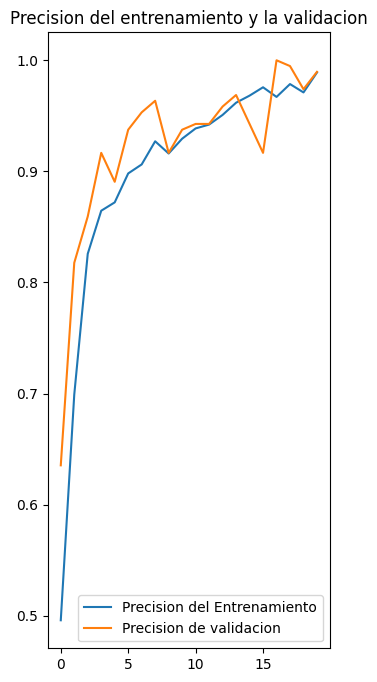

In [51]:
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(range(EPOCHS),acc,label="Precision del Entrenamiento")
plt.plot(range(EPOCHS),val_acc,label="Precision de validacion")
plt.legend(loc="lower right")
plt.title("Precision del entrenamiento y la validacion")


Primera imagen del batch de prueba
Etiqueta de la primera imagen:  Potato___Late_blight
1/1 [==============================] - 0s 357ms/step
Etiqueta predicha: Potato___Late_blight


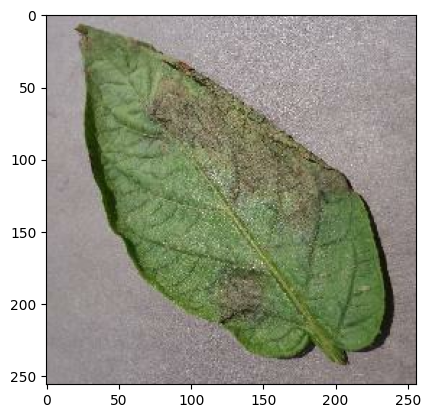

In [56]:
for images_batch,labels_batch in test_ds.take(1):
    firts_image=images_batch[0].numpy().astype('uint8')
    firts_label=labels_batch[0].numpy()
    print("Primera imagen del batch de prueba")
    plt.imshow(firts_image)
    print("Etiqueta de la primera imagen: ", class_names[firts_label])
    batch_prediction=model.predict(images_batch)
    print("Etiqueta predicha:",class_names[np.argmax(batch_prediction[0])])

In [57]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

1/1 [==============================] - 0s 36ms/step


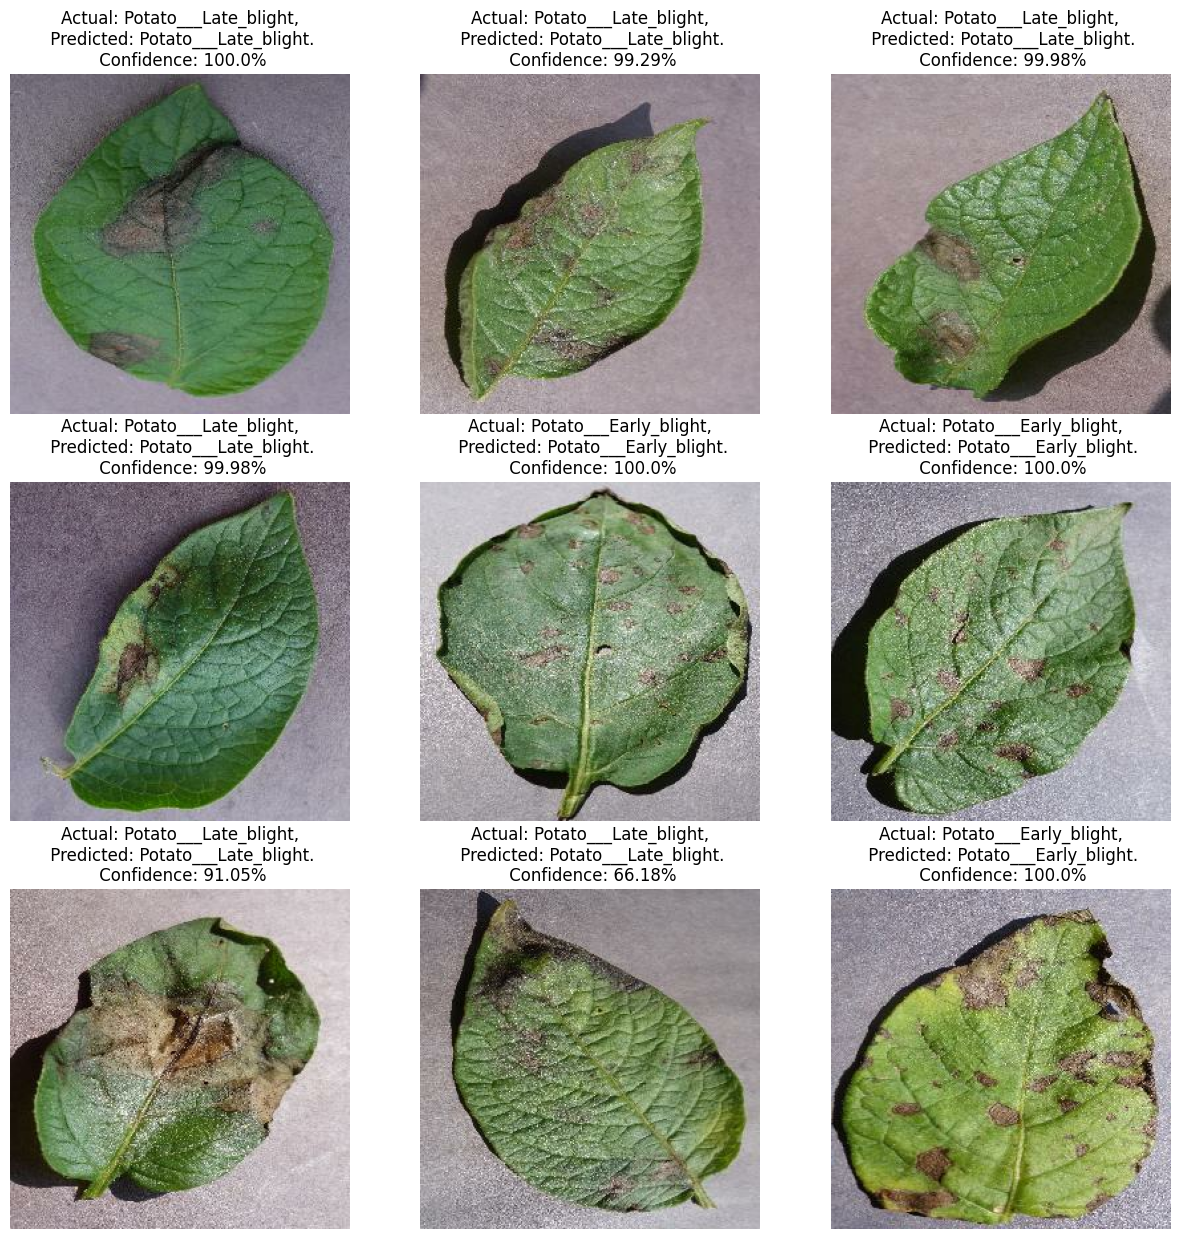

In [58]:
plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]] 
        
        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")
        
        plt.axis("off")

In [60]:
model_version=1
model.save(f"./model/{model_version}")


INFO:tensorflow:Assets written to: ./model/1\assets


INFO:tensorflow:Assets written to: ./model/1\assets
